# Exploratory Data Analysis

In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 01 . Event Participation Prediction (Regression)

In [2]:
# Loading the CSV
participation_df = pd.read_csv("../data/participation_dataset.csv")
participation_df.head()

,eventId,category,location,startDate,startTime,maxVolunteers,requiredSkillId,attendance_count
0,26,Environment,Negombo Beach,2026-02-21,09:00:00,30,6,8
1,27,Community,Raddolugama Public Library,2026-02-21,15:00:00,20,0,6
2,28,Education,Alawathupitiya School,2026-02-21,19:00:00,8,1,0
3,29,Health,Raddolugama Primary School,2026-02-23,12:30:00,20,3,7
4,30,Community,Alawathupitiya School,2026-02-23,18:00:00,20,12,18


In [3]:
#Shape
participation_df.shape

(51, 8)

In [4]:
# Info
participation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   eventId           51 non-null     int64
 1   category          51 non-null     str  
 2   location          51 non-null     str  
 3   startDate         51 non-null     str  
 4   startTime         51 non-null     str  
 5   maxVolunteers     51 non-null     int64
 6   requiredSkillId   51 non-null     int64
 7   attendance_count  51 non-null     int64
dtypes: int64(4), str(4)
memory usage: 3.3 KB


In [5]:
# Missing Values
participation_df.isnull().sum()

eventId             0
category            0
location            0
startDate           0
startTime           0
maxVolunteers       0
requiredSkillId     0
attendance_count    0
dtype: int64

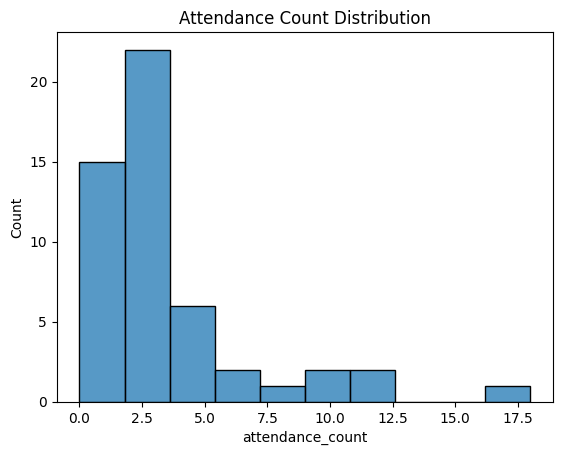

attendance_count
2     27.450980
0     25.490196
3     15.686275
4      7.843137
12     3.921569
10     3.921569
5      3.921569
1      3.921569
8      1.960784
6      1.960784
7      1.960784
18     1.960784
Name: proportion, dtype: float64

In [18]:
# Target Distribution (attendance_count)
sns.histplot(participation_df['attendance_count'], bins=10)
plt.title("Attendance Count Distribution")
plt.show()

# Check distribution percentage
participation_df['attendance_count'].value_counts(normalize=True) * 100

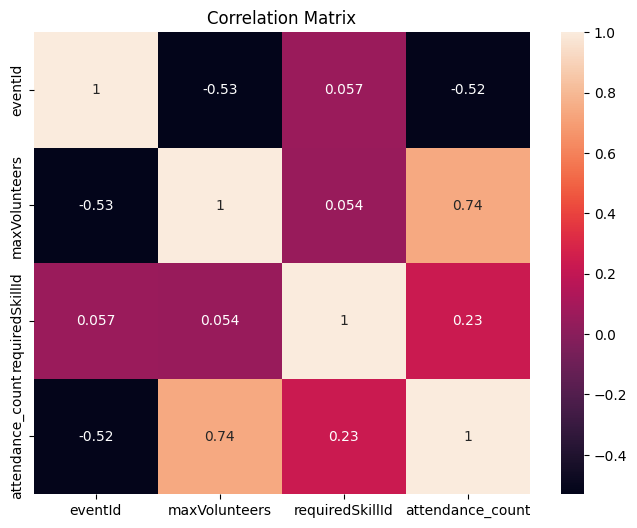

In [7]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(participation_df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

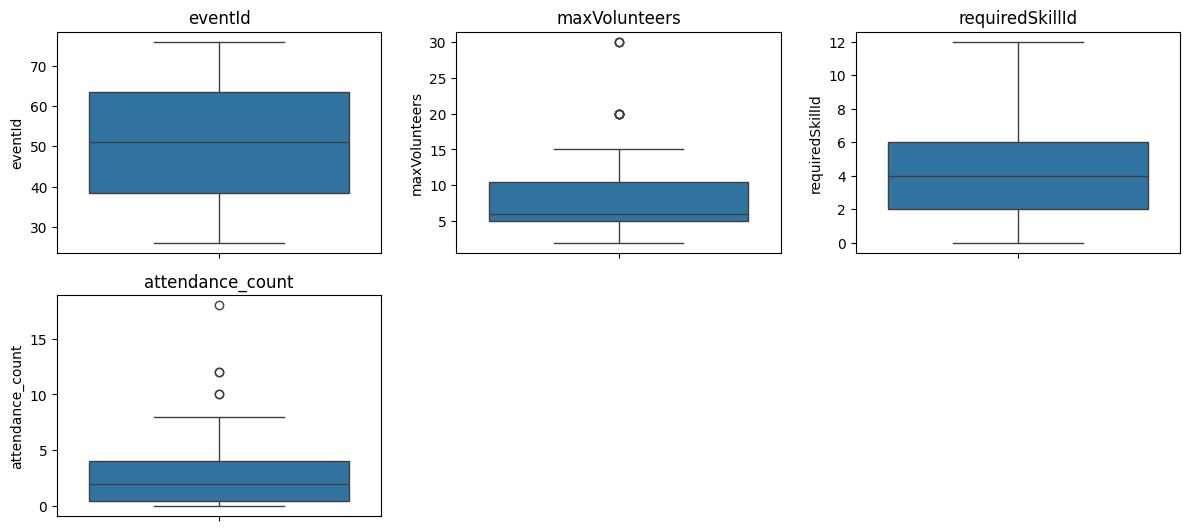

In [ ]:
# Boxplot
num_cols_participation = participation_df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols_participation):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=participation_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### 02 . Smart Volunteer Recommendation (Classification)

In [12]:
# Loading the CSV
recommendation_df = pd.read_csv("../data/recommendation_dataset.csv")
recommendation_df.head()

,userId,eventId,user_location,event_location,requiredSkillId,volunteer_skill,category,attended
0,50,26,Kandana,Negombo Beach,6,11,Environment,1
1,51,26,Kelaniya,Negombo Beach,6,4,Environment,1
2,52,26,Kandana,Negombo Beach,6,6,Environment,1
3,53,26,Seeduwa,Negombo Beach,6,11,Environment,0
4,54,26,City 5,Negombo Beach,6,2,Environment,1


In [13]:
# Shape
recommendation_df.shape

(245, 8)

In [14]:
# Info
recommendation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   userId           245 non-null    int64
 1   eventId          245 non-null    int64
 2   user_location    245 non-null    str  
 3   event_location   245 non-null    str  
 4   requiredSkillId  245 non-null    int64
 5   volunteer_skill  245 non-null    int64
 6   category         245 non-null    str  
 7   attended         245 non-null    int64
dtypes: int64(5), str(3)
memory usage: 15.4 KB


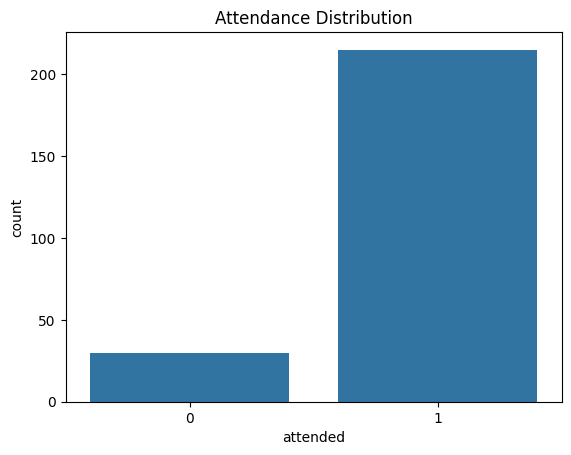

attended
1    87.755102
0    12.244898
Name: proportion, dtype: float64


In [20]:
# Target Distribution
sns.countplot(x='attended', data=recommendation_df)
plt.title("Attendance Distribution")
plt.show()

# Class distribution in percentage
print(recommendation_df['attended'].value_counts(normalize=True) * 100)

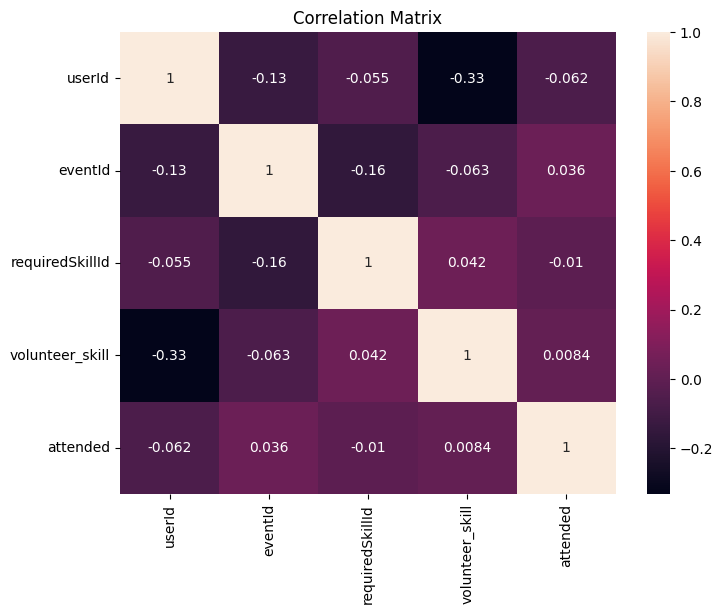

In [16]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(recommendation_df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

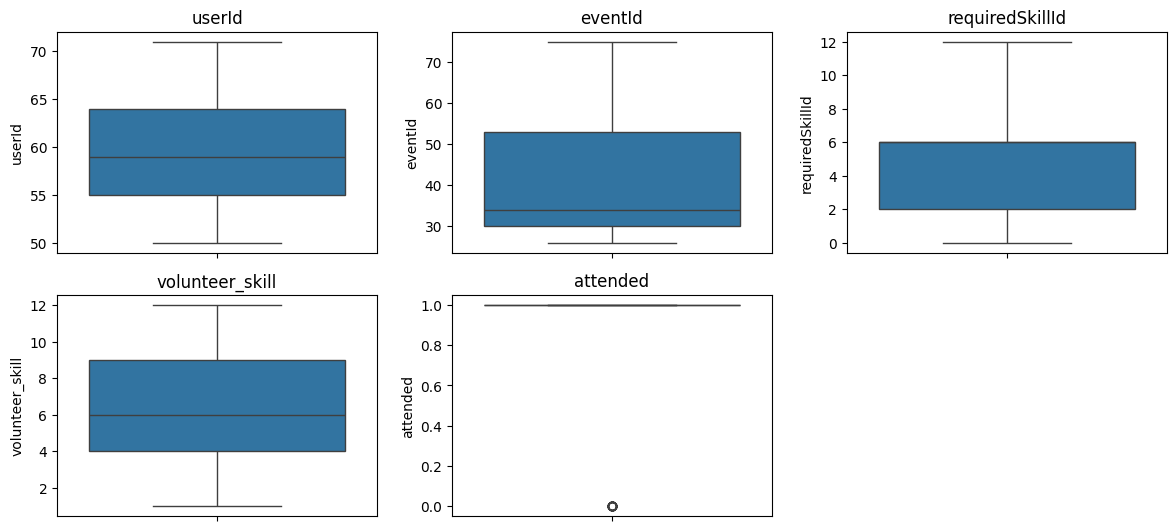

In [17]:
# Boxplot
num_cols_recommendation = recommendation_df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols_recommendation):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=recommendation_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()